<a href="https://colab.research.google.com/github/MahuL88/Competition/blob/main/HousePrice/House_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price

## Data Collecting and Loading

In [61]:
! pip install optuna

In [62]:
!unzip house-prices-advanced-regression-techniques.zip

Archive:  house-prices-advanced-regression-techniques.zip
replace data_description.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data_description.txt    
replace sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sample_submission.csv   
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: test.csv                
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train.csv               


In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import sklearn
import optuna
import json
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from flask import Flask, request, jsonify
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [64]:
test = pd.read_csv("/content/test.csv")
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [65]:
train = pd.read_csv("/content/train.csv")
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


##  Data Cleaning and Transformation

### Data Train

In [66]:
# Menampilkan ringkasan informasi dari dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [67]:
# Menampilkan statistik deskriptif dari dataset
train.describe(include="all")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [68]:
# Memeriksa jumlah nilai yang hilang di setiap kolom
missing_values = train.isnull().sum()
missing_values[missing_values > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


Beberapa kolom-kolom tersebut bukanlah data hilang (Missing Value), melainkan sebuah informasi berharga bahwa rumah tersebut tidak memiliki fasilitas itu (seperti: tidak punya kolam renang, tidak punya basement, atau tidak punya garasi) seperti yang tertera pada data description Kaggle House Prices Dataset. sehingga, cukup diubah datanya menjadi None dan 0.

In [69]:
kategori_no_facility = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond'
]

numerik_no_facility = [
    'BsmtFinSF1', 'GarageYrBlt', 'GarageCars', 'GarageArea'
]

In [70]:
# Isi kolom fasilitas khusus dengan teks 'None' agar dibaca sebagai kategori resmi
for col in kategori_no_facility:
    if col in train.columns:
        train[col] = train[col].fillna('None')

# Isi kolom numerik khusus fasilitas dengan angka 0
for col in numerik_no_facility:
    if col in train.columns:
        train[col] = train[col].fillna(0)

### Drop kolom dengan feature importance

Berdasarkan analisis `feature_importances_` model GBR (pada bagian setelah hyp), kolom `MiscFeature`, `PoolQC`, `Alley`, dan `Fence` **hampir tidak pernah dipakai model** (importance 0.0000–0.0001) karena >95% barisnya bernilai `'None'` , sehingga kolom tsb di drop

In [71]:
# Drop Kolom
kolom_tidak_berguna = ['MiscFeature', 'PoolQC', 'Alley', 'Fence']
train = train.drop(columns=[c for c in kolom_tidak_berguna if c in train.columns])
print("Kolom di-drop dari train:", [c for c in kolom_tidak_berguna])

Kolom di-drop dari train: ['MiscFeature', 'PoolQC', 'Alley', 'Fence']


### Ordinal encoding untuk kolom kualitas/rating

Beberapa kolom kategorikal sebenarnya punya **urutan** (ordinal), bukan sekadar label nominal, sesuai `data_description.txt` (seperti  `Ex > Gd > TA > Fa > Po`).

In [72]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
bsmt_exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
bsmt_fintype_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

ordinal_maps = {
    'ExterQual': quality_map,
    'ExterCond': quality_map,
    'BsmtQual': quality_map,
    'BsmtCond': quality_map,
    'HeatingQC': quality_map,
    'KitchenQual': quality_map,
    'FireplaceQu': quality_map,
    'GarageQual': quality_map,
    'GarageCond': quality_map,
    'BsmtExposure': bsmt_exposure_map,
    'BsmtFinType1': bsmt_fintype_map,
    'BsmtFinType2': bsmt_fintype_map,
}

for col, mapping in ordinal_maps.items():
    if col in train.columns:
        train[col] = train[col].map(mapping)

print("Kolom yang sudah di-ordinal-encode:", list(ordinal_maps.keys()))


Kolom yang sudah di-ordinal-encode: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']


In [73]:
# pisahkan kolom yang memiliki missing value lebih dari 75% dan kurang dari 75%
missing_values = train.isnull().sum()
less = missing_values[missing_values < 1000].index
over = missing_values[missing_values >= 1000].index

In [74]:
# mengisi nilai yang hilang dengan median untuk kolom numerik yang ditentukan oleh less.
numeric_features = train[less].select_dtypes(include=['number']).columns
train[numeric_features] = train[numeric_features].fillna(train[numeric_features].median())

In [75]:
# mengisi nilai yang hilang dengan modus/kategori baru(unknown) untuk kolom kategori
kategorical_features = train[less].select_dtypes(include=['object']).columns

for column in kategorical_features:
    train[column] = train[column].fillna(train[column].mode()[0])

# Menghapus kolom dengan terlalu banyak nilai yang hilang
df = train.drop(columns=over)

In [76]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

,0


cara lain proses outlier
median = df['column_name'].median()
df['column_name'] = df['column_name'].apply(lambda x: median if x < (Q1 - 1.5  IQR) or x > (Q3 + 1.5  IQR) else x)
atau

Mengganti outlier dengan nilai batas terdekat
df['column_name'] = df['column_name'].apply(lambda x: (Q1 - 1.5  IQR) if x < lower_bound else (Q3 + 1.5  IQR) if x > (Q3 + 1.5 * IQR) else x)




In [77]:
# Standardisasi fitur numerik
scaler_train = StandardScaler()
# make a copy, agar target tidak terstandarisasi
numeric_features_scaled = list(numeric_features)
if 'SalePrice' in numeric_features_scaled:
    numeric_features_scaled.remove('SalePrice')

df[numeric_features_scaled] = scaler_train.fit_transform(df[numeric_features_scaled])

Text(0.5, 1.0, 'Histogram Setelah Standardisasi')

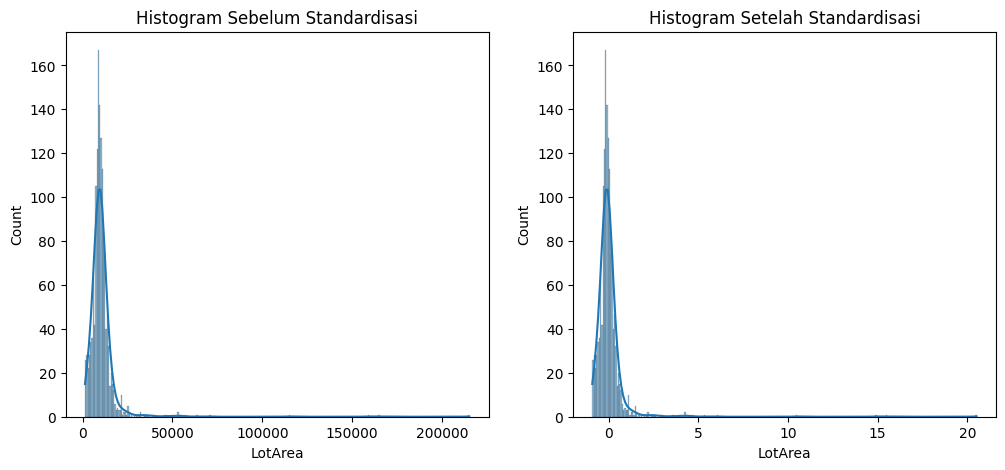

In [78]:
# Histogram Sebelum Standardisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(train[numeric_features[3]], kde=True)
plt.title("Histogram Sebelum Standardisasi")

# Histogram Setelah Standardisasi
plt.subplot(1, 2, 2)
sns.histplot(df[numeric_features[3]], kde=True)
plt.title("Histogram Setelah Standardisasi")

In [79]:
# Mengidentifikasi baris duplikat
duplicates = df.duplicated()

print("Baris duplikat:")
print(df[duplicates])

Baris duplikat:
Empty DataFrame
Columns: [Id, MSSubClass, MSZoning, LotFrontage, LotArea, Street, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, Heating, HeatingQC, CentralAir, Electrical, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional, Fireplaces, FireplaceQu, GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal, MoSold, YrSold, SaleType, SaleCondition, SalePrice]
Index: []

[0 rows x 77 columns]


In [80]:
# Inisialisasi LabelEncoder
category_features = df.select_dtypes(include=['object']).columns
df_lencoder = df.copy()

train_encoders = {}

for col in category_features:
    le = LabelEncoder()
    df_lencoder[col] = le.fit_transform(df[col])
    train_encoders[col] = le

joblib.dump(scaler_train, 'scaler_train.joblib')
joblib.dump(train_encoders, 'train_encoders.joblib')

df_lencoder

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,-1.730865,0.073375,3,-0.220875,-0.207142,1,3,3,0,4,...,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,0.138777,8,4,208500
1,-1.728492,-0.872563,3,0.460320,-0.091886,1,3,3,0,2,...,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.489110,-0.614439,8,4,181500
2,-1.726120,0.073375,3,-0.084636,0.073480,1,0,3,0,4,...,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.990891,0.138777,8,4,223500
3,-1.723747,0.309859,3,-0.447940,-0.096897,1,0,3,0,0,...,4.092524,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,-1.367655,8,0,140000
4,-1.721374,0.073375,3,0.641972,0.375148,1,0,3,0,2,...,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,2.100892,0.138777,8,4,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1.721374,0.073375,3,-0.357114,-0.260560,1,3,3,0,4,...,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.620891,-0.614439,8,4,175000
1456,1.723747,-0.872563,3,0.687385,0.266407,1,3,3,0,4,...,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.599111,1.645210,8,4,210000
1457,1.726120,0.309859,3,-0.175462,-0.147810,1,3,3,0,4,...,-0.359325,-0.116339,-0.270208,-0.068692,4.953112,-0.489110,1.645210,8,4,266500
1458,1.728492,-0.872563,3,-0.084636,-0.080160,1,3,3,0,4,...,1.473789,-0.116339,-0.270208,-0.068692,-0.087688,-0.859110,1.645210,8,4,142125


In [81]:
df_lencoder.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   float64
 1   MSSubClass     1460 non-null   float64
 2   MSZoning       1460 non-null   int64  
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   float64
 5   Street         1460 non-null   int64  
 6   LotShape       1460 non-null   int64  
 7   LandContour    1460 non-null   int64  
 8   Utilities      1460 non-null   int64  
 9   LotConfig      1460 non-null   int64  
 10  LandSlope      1460 non-null   int64  
 11  Neighborhood   1460 non-null   int64  
 12  Condition1     1460 non-null   int64  
 13  Condition2     1460 non-null   int64  
 14  BldgType       1460 non-null   int64  
 15  HouseStyle     1460 non-null   int64  
 16  OverallQual    1460 non-null   float64
 17  OverallCond    1460 non-null   float64
 18  YearBuil

### Data Test

In [82]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [83]:
test.describe(include="all")

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
count,1459.000000,1459.000000,1455,1232.000000,1459.000000,1459,107,1459,1459,1457,...,1459.000000,1459.000000,3,290,51,1459.000000,1459.000000,1459.000000,1458,1459
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,1,...,NaN,NaN,2,4,3,NaN,NaN,NaN,9,6
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,NaN,Ex,MnPrv,Shed,NaN,NaN,NaN,WD,Normal
freq,NaN,NaN,1114,NaN,NaN,1453,70,934,1311,1457,...,NaN,NaN,2,172,46,NaN,NaN,NaN,1258,1204
mean,2190.000000,57.378341,NaN,68.580357,9819.161069,NaN,NaN,NaN,NaN,NaN,...,17.064428,1.744345,NaN,NaN,NaN,58.167923,6.104181,2007.769705,NaN,NaN
std,421.321334,42.746880,NaN,22.376841,4955.517327,NaN,NaN,NaN,NaN,NaN,...,56.609763,30.491646,NaN,NaN,NaN,630.806978,2.722432,1.301740,NaN,NaN
min,1461.000000,20.000000,NaN,21.000000,1470.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN
25%,1825.500000,20.000000,NaN,58.000000,7391.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,0.000000,4.000000,2007.000000,NaN,NaN
50%,2190.000000,50.000000,NaN,67.000000,9399.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN
75%,2554.500000,70.000000,NaN,80.000000,11517.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN


In [84]:
# Simpan kolom Id
id_test = test['Id']

In [85]:
# Memeriksa jumlah nilai yang hilang di setiap kolom
missing_values_test = test.isnull().sum()
missing_values_test[missing_values_test > 0]

,0
MSZoning,4
LotFrontage,227
Alley,1352
Utilities,2
Exterior1st,1
Exterior2nd,1
MasVnrType,894
MasVnrArea,15
BsmtQual,44
BsmtCond,45


In [86]:
for col in kategori_no_facility:
    if col in test.columns:
        test[col] = test[col].fillna('None')

for col in numerik_no_facility:
    if col in test.columns:
        test[col] = test[col].fillna(0)

In [87]:
# drop seperti perlakuan pada data train
test = test.drop(columns=[c for c in kolom_tidak_berguna if c in test.columns])
print("Kolom di-drop dari test:", [c for c in kolom_tidak_berguna])

Kolom di-drop dari test: ['MiscFeature', 'PoolQC', 'Alley', 'Fence']


In [88]:
# encode utk test
for col, mapping in ordinal_maps.items():
    if col in test.columns:
        test[col] = test[col].map(mapping)

print("Kolom test yang sudah di-ordinal-encode:", list(ordinal_maps.keys()))


Kolom test yang sudah di-ordinal-encode: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']


In [89]:
# pisahkan kolom yang memiliki missing value lebih dari 75% dan kurang dari 75%
missing_values_test = test.isnull().sum()
less_test = missing_values_test[missing_values_test < 1000].index
over_test = missing_values_test[missing_values_test >= 1000].index

In [90]:
# mengisi nilai yang hilang dengan median untuk kolom numerik yang ditentukan oleh less.
numeric_features_test = test[less_test].select_dtypes(include=['number']).columns.tolist()
if 'Id' in numeric_features_test:
    numeric_features_test.remove('Id')
test[numeric_features_test] = test[numeric_features_test].fillna(test[numeric_features_test].median())

In [91]:
# mengisi nilai yang hilang dengan modus/kategori baru(unknown) untuk kolom kategori
kategorical_features_test = test[less_test].select_dtypes(include=['object']).columns

for column in kategorical_features_test:
    test[column] = test[column].fillna(test[column].mode()[0])

dft = test.drop(columns=over_test)

In [92]:
# Masukkan kembali Id (pastikan aman dari over_test)
dft['Id'] = id_test

In [93]:
missing_values_test = dft.isnull().sum()
missing_values_test[missing_values_test > 0]

,0


In [94]:
# load kembali scaler dan label encoder
scaler_train = joblib.load('scaler_train.joblib')
train_encoders = joblib.load('train_encoders.joblib')
test_scaled = dft.copy()

In [95]:
numeric_features_scaled = list(scaler_train.feature_names_in_)

# memastikan fitur kategori tidak ikut di scaling
for col in test_scaled.columns:
    if col in train_encoders:
        if col in numeric_features_scaled:
            numeric_features_scaled.remove(col)

test_scaled[numeric_features_scaled] = scaler_train.transform(test_scaled[numeric_features_scaled])

Text(0.5, 1.0, 'Histogram data test Setelah Standardisasi')

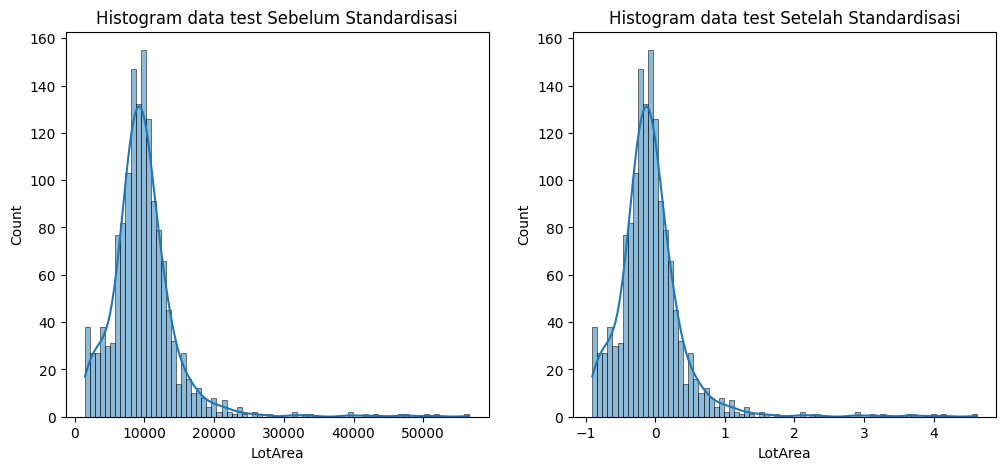

In [96]:
# Histogram Sebelum Standardisasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(test[numeric_features_test[2]], kde=True)
plt.title("Histogram data test Sebelum Standardisasi")

# Histogram Setelah Standardisasi
plt.subplot(1, 2, 2)
sns.histplot(test_scaled[numeric_features_test[2]], kde=True)
plt.title("Histogram data test Setelah Standardisasi")

In [97]:
# Mengidentifikasi baris duplikat
duplicates_test = test_scaled.duplicated()

print("Baris duplikat pada data test:")
print(test_scaled[duplicates_test])

Baris duplikat pada data test:
Empty DataFrame
Columns: [Id, MSSubClass, MSZoning, LotFrontage, LotArea, Street, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, Heating, HeatingQC, CentralAir, Electrical, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional, Fireplaces, FireplaceQu, GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal, MoSold, YrSold, SaleType, SaleCondition]
Index: []

[0 rows x 76 columns]


In [98]:
# Inisialisasi LabelEncoder pada data test ini
test_lencoder = test_scaled.copy()

for col in kategorical_features_test:
    if col in train_encoders:
        le = train_encoders[col]
        kategori_sah = set(le.classes_)

        nilai_aman = test_lencoder[col].apply(lambda x: x if x in kategori_sah else le.classes_[0])

        # Terapkan transformasi angka secara konsisten
        test_lencoder[col] = le.transform(nilai_aman)

# Menampilkan hasil
test_lencoder

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1.733238,-0.872563,2,0.460320,0.110763,1,3,3,0,4,...,-0.704483,-0.359325,-0.116339,1.882709,-0.068692,-0.087688,-0.119110,1.645210,8,4
1,1.735610,-0.872563,3,0.505733,0.375850,1,0,3,0,0,...,-0.160950,-0.359325,-0.116339,-0.270208,-0.068692,25.116309,-0.119110,1.645210,8,4
2,1.737983,0.073375,3,0.187842,0.332053,1,0,3,0,4,...,-0.191147,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-1.229111,1.645210,8,4
3,1.740356,0.073375,3,0.369494,-0.054002,1,0,3,0,4,...,-0.160950,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.119110,1.645210,8,4
4,1.742728,1.492282,3,-1.219961,-0.552407,1,0,1,0,4,...,0.533564,-0.359325,-0.116339,2.313293,-0.068692,-0.087688,-1.969111,1.645210,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,5.183104,2.438219,4,-2.219047,-0.859988,1,3,3,0,4,...,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.119110,-1.367655,8,4
1455,5.185477,2.438219,4,-2.219047,-0.864197,1,3,3,0,4,...,-0.342128,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,-0.859110,-1.367655,8,0
1456,5.187849,-0.872563,3,4.093359,0.950423,1,3,3,0,4,...,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,-0.087688,0.990891,-1.367655,8,0
1457,5.190222,0.664586,3,-0.357114,-0.007600,1,3,3,0,4,...,-0.221343,-0.359325,-0.116339,-0.270208,-0.068692,1.323736,0.250891,-1.367655,8,4


In [99]:
# Menghitung jumlah dan persentase missing values di setiap kolom
missing_values = df_lencoder.isnull().sum()
missing_percentage = (missing_values / len(df_lencoder)) * 100

missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

missing_data[missing_data['Missing Values'] > 0]  # Menampilkan kolom dengan missing values

,Missing Values,Percentage


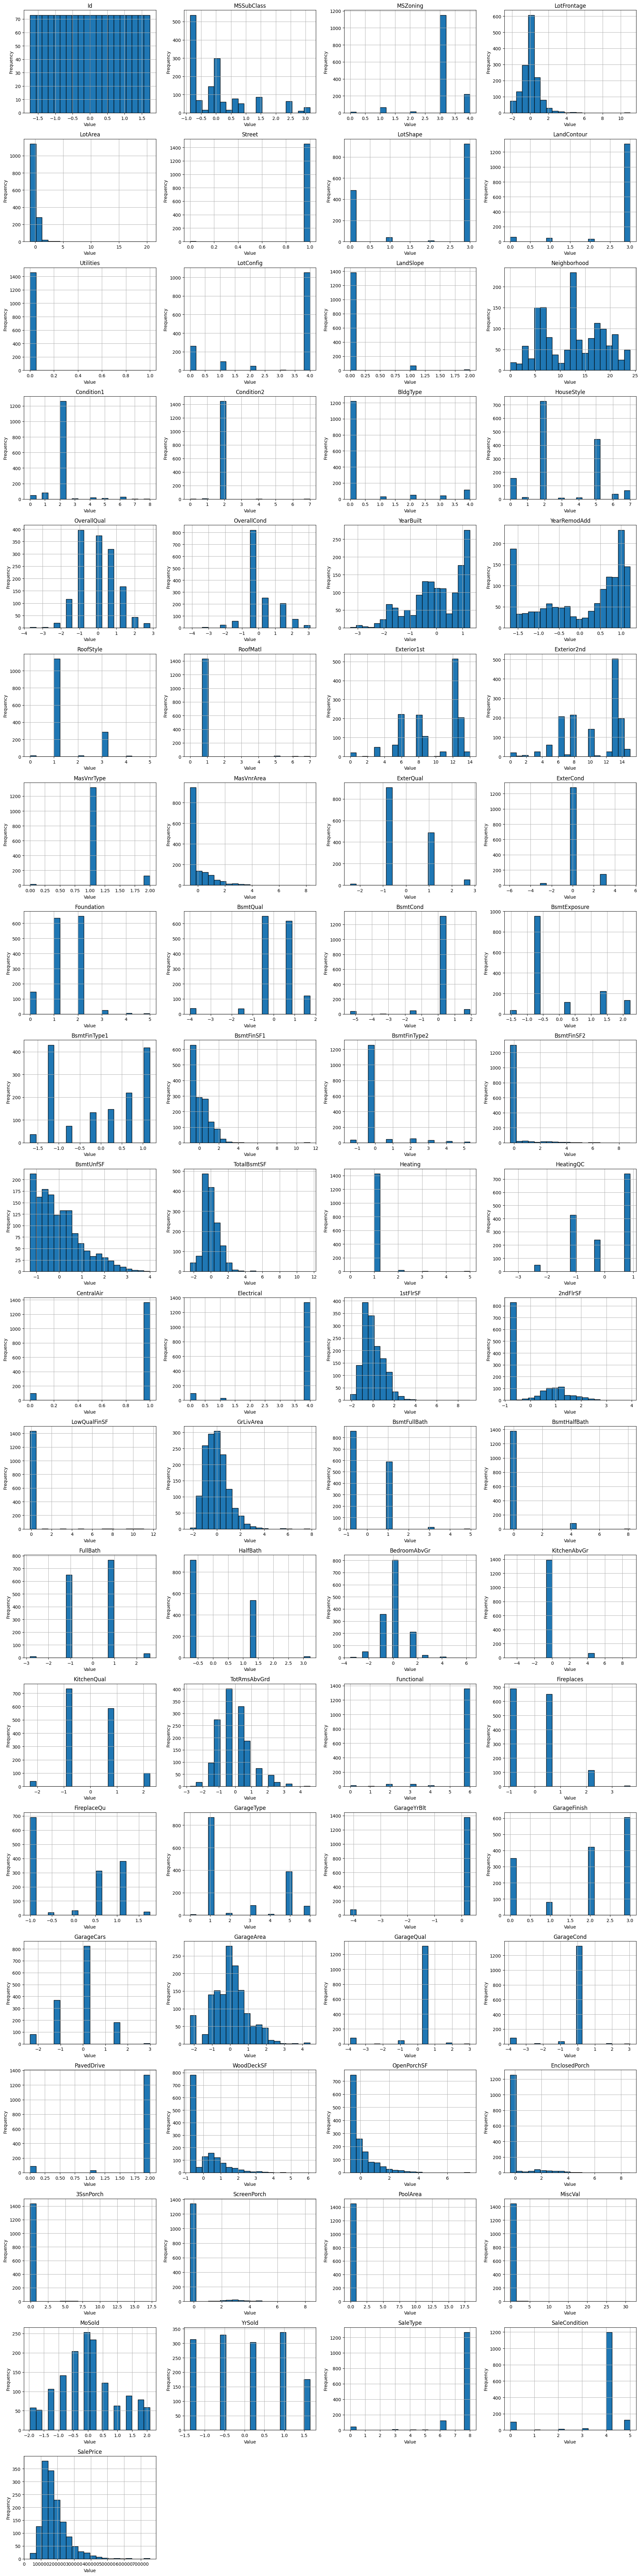

In [100]:
# Menghitung jumlah variabel
num_vars = df_lencoder.shape[1]

# Menentukan jumlah baris dan kolom untuk grid subplot
n_cols = 4  # Jumlah kolom yang diinginkan
n_rows = -(-num_vars // n_cols)  # Ceiling division untuk menentukan jumlah baris

# Membuat subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))

# Flatten axes array untuk memudahkan iterasi jika diperlukan
axes = axes.flatten()

# Plot setiap variabel
for i, column in enumerate(df_lencoder.columns):
    df_lencoder[column].hist(ax=axes[i], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Menghapus subplot yang tidak terpakai (jika ada)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Menyesuaikan layout agar lebih rapi
plt.tight_layout()
plt.show()

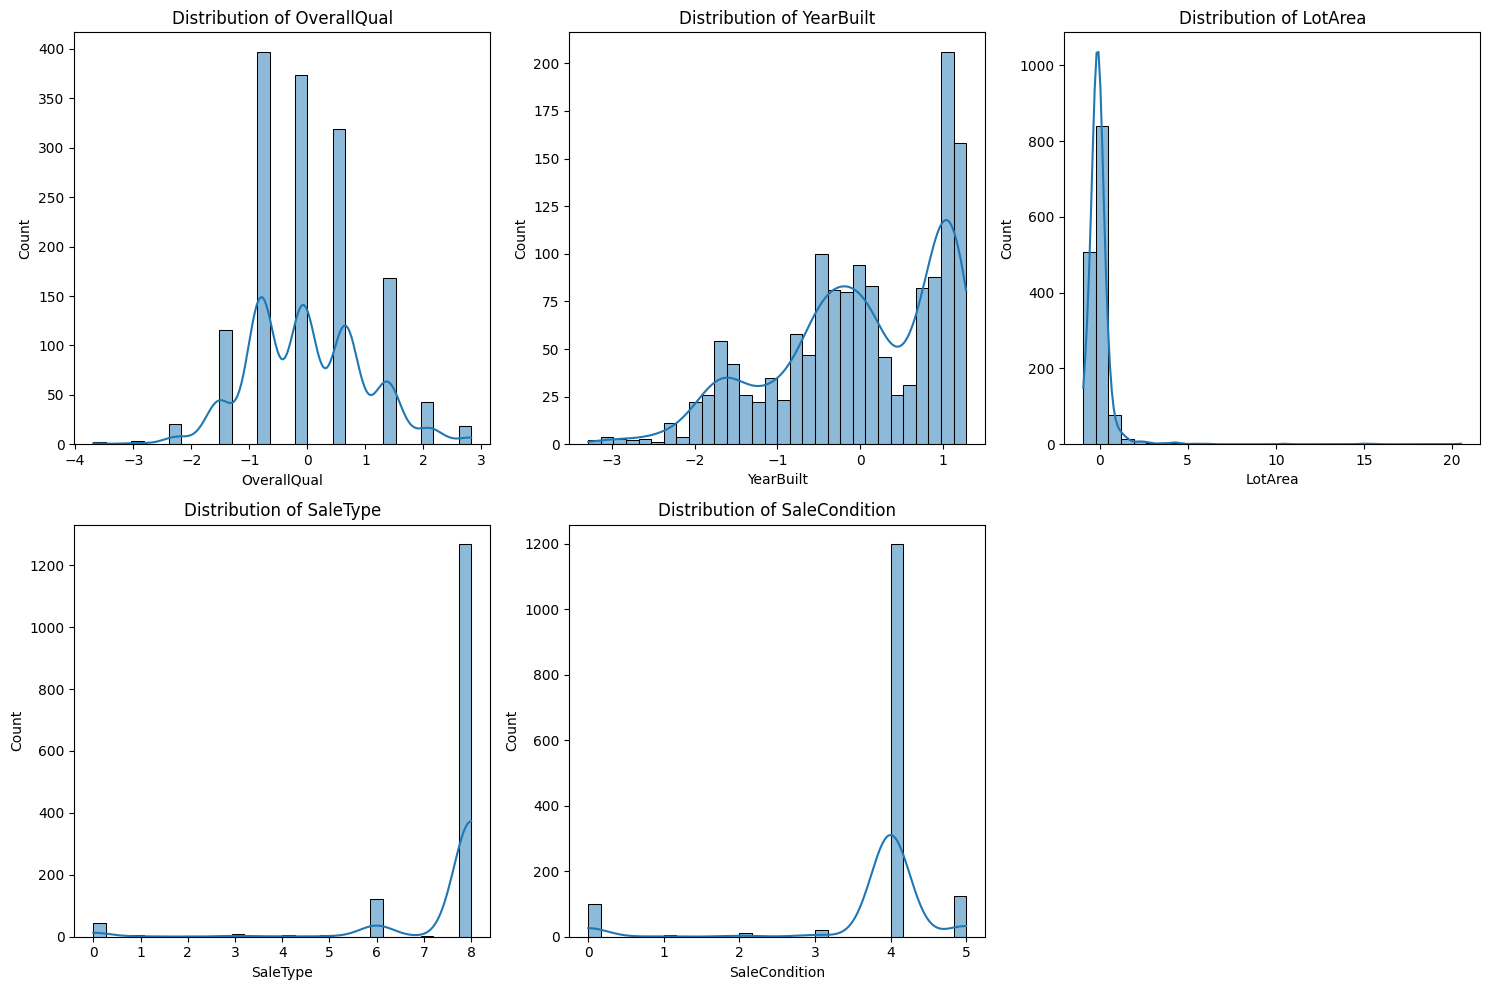

In [101]:
# Visualisasi distribusi data untuk beberapa kolom
columns_to_plot = ['OverallQual', 'YearBuilt', 'LotArea', 'SaleType', 'SaleCondition']

plt.figure(figsize=(15, 10))
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_lencoder[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()



1.   OverallQual: sebagian besar data terkonsentrasi di sekitar nilai tengah dengan distribusi miring ke kanan.
2.   YearBuilt: distribusi cenderung normal dengan beberapa lonjakan pada tahun tertentu, menunjukkan periode pembangunan rumah yang lebih aktif.
3.   LotArea: distribusinya tidak simetris karena adanya beberapa outlier yang signifikan pada sisi kanan (lot area yang sangat besar).
4.   SaleType: kategori tertentu mendominasi distribusi, menunjukkan preferensi atau pola tertentu dalam tipe penjualan.
5.   SaleCondition: mirip dengan SaleType, beberapa kondisi penjualan lebih umum dibandingkan lainnya.



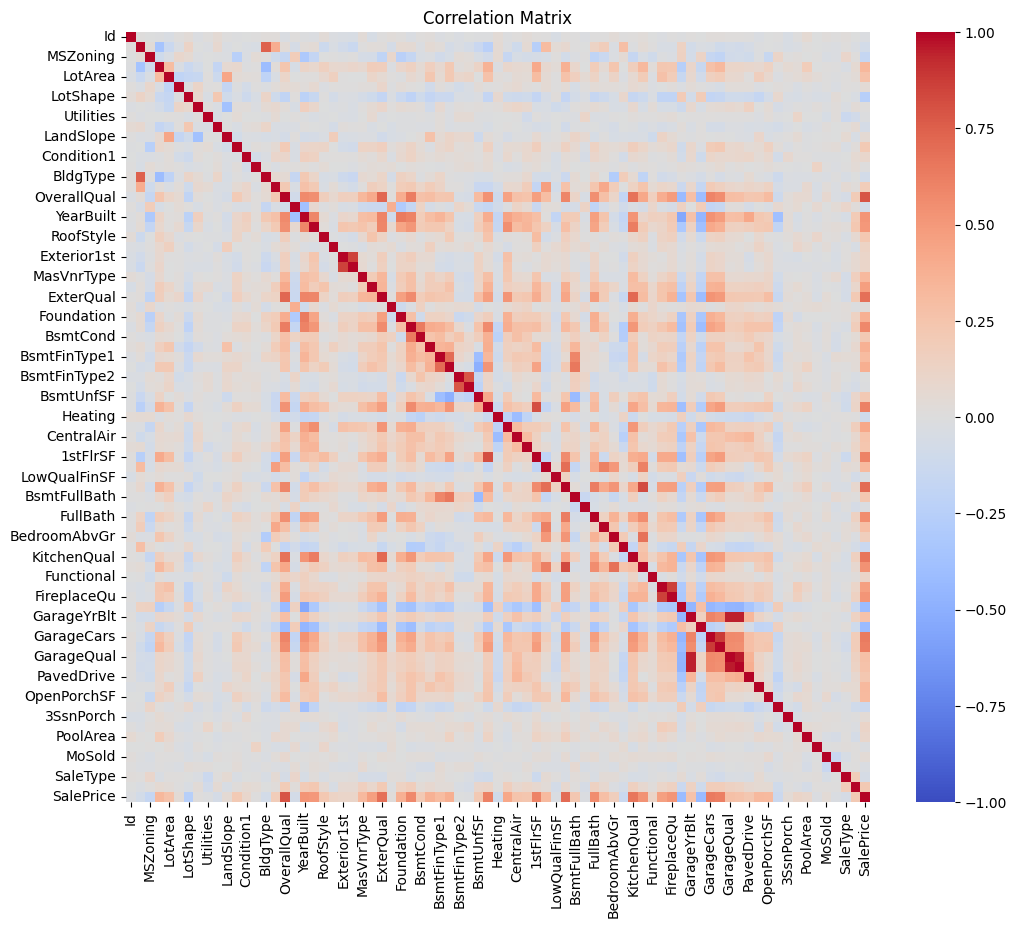

In [102]:
# Visualisasi korelasi antar variabel numerik
plt.figure(figsize=(12, 10))
correlation_matrix = df_lencoder.corr()

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

1.  Korelasi Positif: nilai korelasi positif menunjukkan bahwa saat satu variabel meningkat, variabel lain juga cenderung meningkat. Nilai korelasi +1 menunjukkan korelasi positif sempurna.
2.  Korelasi Negatif: nilai korelasi negatif menunjukkan bahwa saat satu variabel meningkat, variabel lain cenderung menurun. Nilai korelasi -1 menunjukkan korelasi negatif sempurna.
3.  Korelasi Nol: nilai korelasi 0 menunjukkan bahwa tidak ada hubungan linier antara dua variabel.

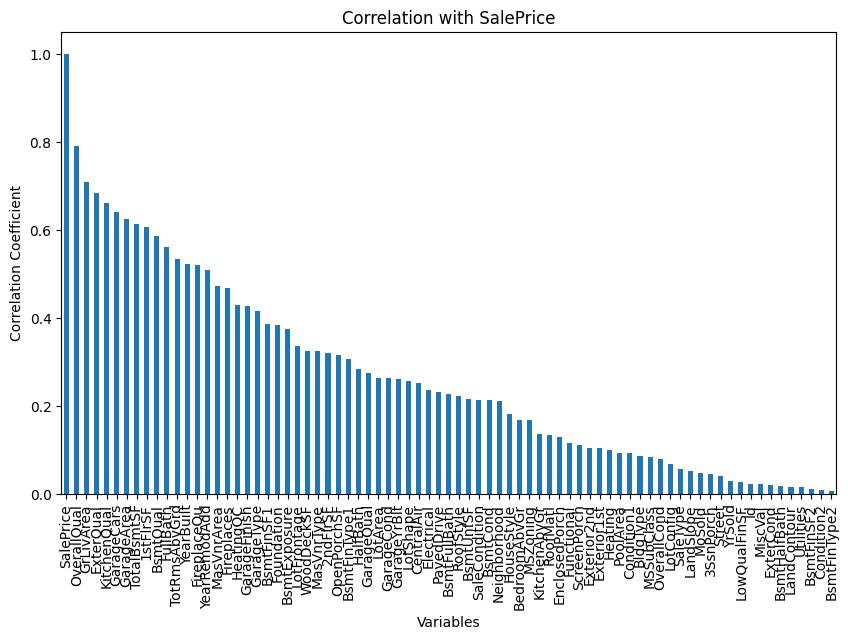

In [103]:
# Menghitung korelasi antara variabel target dan semua variabel lainnya
target_corr = df_lencoder.corr()['SalePrice']

# (Opsional) Mengurutkan hasil korelasi berdasarkan korelasi
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title(f'Correlation with SalePrice')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()

Berdasarkan matriks korelasi dari masing-masing kolom terhadap SalePrice di atas, dapat ditentukan threshold atau batasan korelasi untuk menentukan kolom mana saja yang akan dipilih untuk pelatihan model.
selain itu, Pengembang properti atau investor harus mempertimbangkan ukuran ruang tinggal dan garasi sebagai faktor utama yang memengaruhi nilai jual. dan juga Outliers yang ditemukan harus dianalisis lebih lanjut untuk memahami apakah mereka mencerminkan kondisi pasar yang unik atau kesalahan dalam data.

Dari visualisasi tersebut, didapatkan bahwa beberapa kolom sangat rendah korelasinya dengan target sehingga kolom tersebut(dari id hingga terkecil dihapus)

## Training

In [104]:
# Memisahkan fitur (X) dan target (y) pada data train
X = df_lencoder.drop(columns=['SalePrice', 'Id','MiscVal','BsmtHalfBath','LandContour','Utilities','BsmtFinSF2','Condition2'], errors='ignore')
y = df_lencoder['SalePrice']

# membagi dataset menjadi training dan testing
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
# Melatih model 1 dengan algoritma Least Angle Regression
lars = linear_model.Lars(n_nonzero_coefs=1).fit(x_train, y_train)

# Melatih model 2 dengan algoritma Linear Regression
LR = LinearRegression().fit(x_train, y_train)

# Melatih model 3 dengan algoritma Gradient Boosting Regressor
GBR = GradientBoostingRegressor(random_state=184)
GBR.fit(x_train, y_train)

GradientBoostingRegressor(random_state=184)

In [105]:
# Evaluasi pada model LARS
pred_lars = lars.predict(x_test)
mae_lars = mean_absolute_error(y_test, pred_lars)
mse_lars = mean_squared_error(y_test, pred_lars)
r2_lars = r2_score(y_test, pred_lars)

# Membuat dictionary untuk menyimpan hasil evaluasi
data = {
    'MAE': [mae_lars],
    'MSE': [mse_lars],
    'R2': [r2_lars]
}

# Konversi dictionary menjadi DataFrame
df_results = pd.DataFrame(data, index=['Lars'])
df_results

,MAE,MSE,R2
Lars,62018.667856,7.471391e+09,0.025936


In [106]:
# Evaluasi pada model Linear Regression
pred_LR = LR.predict(x_test)
mae_LR = mean_absolute_error(y_test, pred_LR)
mse_LR = mean_squared_error(y_test, pred_LR)
r2_LR = r2_score(y_test, pred_LR)

# Menambahkan hasil evaluasi LR ke DataFrame
df_results.loc['Linear Regression'] = [mae_LR, mse_LR, r2_LR]
df_results

,MAE,MSE,R2
Lars,62018.667856,7.471391e+09,0.025936
Linear Regression,21248.803405,1.167204e+09,0.847829


In [107]:
# Evaluasi pada model Linear Regression
pred_GBR = GBR.predict(x_test)
mae_GBR = mean_absolute_error(y_test, pred_GBR)
mse_GBR = mean_squared_error(y_test, pred_GBR)
r2_GBR = r2_score(y_test, pred_GBR)

# Menambahkan hasil evaluasi LR ke DataFrame
df_results.loc['GradientBoostingRegressor'] = [mae_GBR, mse_GBR, r2_GBR]
df_results

,MAE,MSE,R2
Lars,62018.667856,7.471391e+09,0.025936
Linear Regression,21248.803405,1.167204e+09,0.847829
GradientBoostingRegressor,16765.174020,6.865676e+08,0.910490


### **Kesimpulan**

Berdasarkan hasil evaluasi ketiga model, **Gradient Boosting Regressor (GBR)** dipilih sebagai model terbaik untuk memprediksi harga rumah (`SalePrice`) karena:

1. **GBR secara konsisten menghasilkan MAE paling kecil** dibanding `Lars` dan `Linear Regression`.
2. **Mampu menangani hubungan non-linear** antar fitur.

Performa **LARS** jauh paling buruk (R² mendekati 0), sementara **Linear Regression** cukup baik tapi masih kalah dari GBR dalam hal MAE.


# Hyperparameter

In [108]:
def objective(trial):
    # rentang hyp
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }

    # Inisialisasi model
    model = GradientBoostingRegressor(**params, random_state=184)

    # Gunakan K-Fold Cross Validation (cv=5)
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2', n_jobs=-1)

    # Kembalikan rata-rata skor R2 sebagai target yang ingin dimaksimalkan oleh Optuna
    return scores.mean()

In [109]:
optuna.logging.set_verbosity(optuna.logging.WARNING) # sembunyikan log yang terlalu panjang
study = optuna.create_study(direction='maximize')

In [51]:
study.optimize(objective, n_trials=200)

print("Parameter Terbaik yang Ditemukan:")
print(study.best_params)
print(f"Skor R2 Terbaik saat Cross-Validation: {study.best_value:.4f}")

Parameter Terbaik yang Ditemukan:
{'n_estimators': 255, 'learning_rate': 0.044886618985100664, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 2, 'subsample': 0.8503032274872583}
Skor R2 Terbaik saat Cross-Validation: 0.8771


In [52]:
# Latih Ulang Model Menggunakan Parameter Terbaik
GBR_opt = GradientBoostingRegressor(**study.best_params, random_state=184)
GBR_opt.fit(x_train, y_train)

# Evaluasi Ulang pada Data Internal x_test
pred_GBR_opt = GBR_opt.predict(x_test)
mae_opt = mean_absolute_error(y_test, pred_GBR_opt)
r2_opt = r2_score(y_test, pred_GBR_opt)
print(f"\nPerforma Baru setelah dioptimasi Optuna -> MAE: {mae_opt:.2f} | R2 Score: {r2_opt:.4f}")

# 5. SIMPAN MODEL OPTIMAL KE FILE JOBLIB
joblib.dump(GBR_opt, 'gbr_model.joblib')
print("Model GBR terbaik berhasil disimpan ke 'gbr_model.joblib'!")


Performa Baru setelah dioptimasi Optuna -> MAE: 15770.56 | R2 Score: 0.9130
Model GBR terbaik berhasil disimpan ke 'gbr_model.joblib'!


## Feature Importance (GBR setelah tuning)

In [53]:
# Ambil feature importance dari model GBR yang sudah di-tuning
importances = pd.Series(GBR_opt.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

print("Top 15 fitur paling berpengaruh:")
print(importances_sorted.head(15))

print("\nImportance untuk kolom 'no facility' yang tersisa:")
kolom_dicek = kategori_no_facility + numerik_no_facility
kolom_dicek = [c for c in kolom_dicek if c in importances.index]
print(importances[kolom_dicek].sort_values(ascending=False))


Top 15 fitur paling berpengaruh:
OverallQual     0.545323
GrLivArea       0.113307
2ndFlrSF        0.042375
TotalBsmtSF     0.034236
BsmtFinSF1      0.033459
1stFlrSF        0.022349
GarageCars      0.021349
LotArea         0.017095
YearBuilt       0.013791
GarageArea      0.011168
BsmtQual        0.010190
KitchenQual     0.009930
TotRmsAbvGrd    0.009447
LotFrontage     0.008804
Neighborhood    0.008700
dtype: float64

Importance untuk kolom 'no facility' yang tersisa:
BsmtFinSF1      0.033459
GarageCars      0.021349
GarageArea      0.011168
BsmtQual        0.010190
GarageYrBlt     0.007880
FireplaceQu     0.007215
GarageType      0.005668
BsmtExposure    0.004523
BsmtFinType1    0.002699
GarageCond      0.000724
GarageQual      0.000524
GarageFinish    0.000376
BsmtCond        0.000341
BsmtFinType2    0.000306
dtype: float64


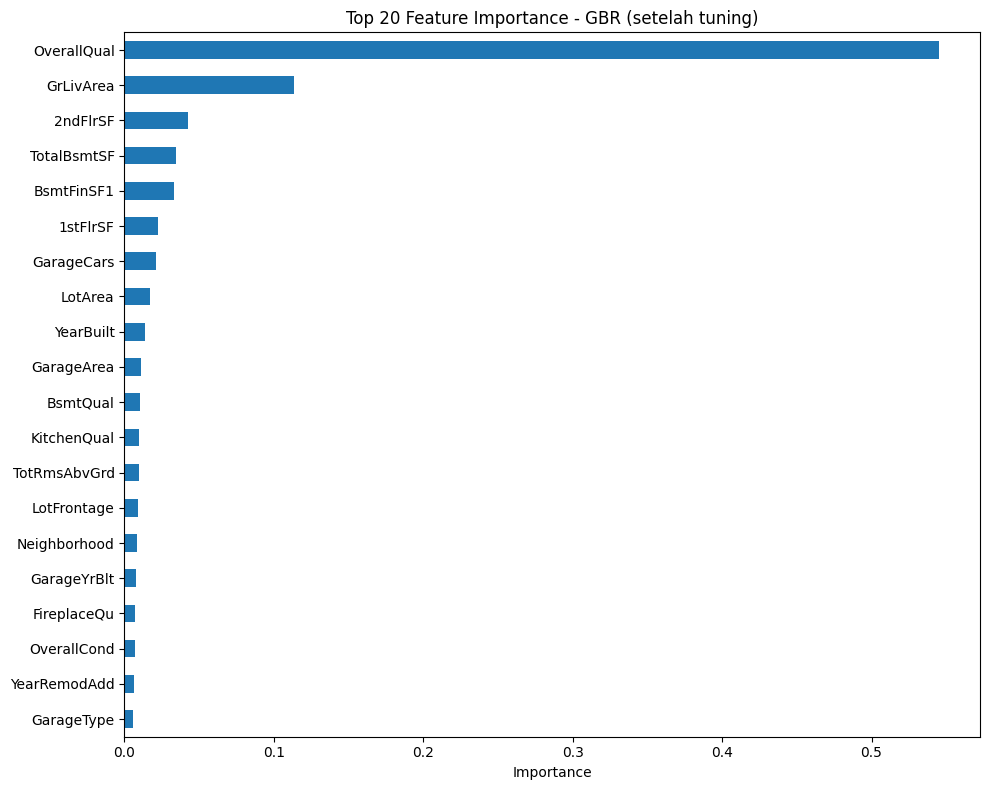

In [54]:
# Visualisasi 20 fitur paling penting
plt.figure(figsize=(10, 8))
importances_sorted.head(20).sort_values().plot(kind='barh')
plt.title('Top 20 Feature Importance - GBR (setelah tuning)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## Save Model

untuk menyimpan model ke dalam sebuah file sehingga bisa digunakan kembali di masa mendatang tanpa perlu melatih ulang model.

In [55]:
# Ambil kolom input dari data latih (tanpa target)
X_train_columns = list(X.columns)

# Pastikan kolom test sesuai dengan kolom train
X_test_final = test_lencoder.loc[:, X_train_columns]

test_predictions = GBR_opt.predict(X_test_final)

hasil = pd.DataFrame({
    'Id': dft['Id'].astype(int),
    'SalePrice': test_predictions # Hasil Prediksi
})

# Simpan hasil prediksi ke file hasil.csv
hasil.to_csv('hasil_prediksi.csv', index=False)

## Deployment

In [56]:
# Ambil 3 baris sampel data
test_raw = pd.read_csv('test.csv')
sample_data = test_raw[numeric_features_scaled].head(3).to_dict(orient='records')

payload = {"data": sample_data}

# Simpan menjadi berkas test.json
with open('test.json', 'w') as f:
    json.dump(payload, f)

In [57]:
%%writefile app.py
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np

app = Flask(__name__)

# Load model dan alat pemrosesnya
model = joblib.load('gbr_model.joblib')
encoders = joblib.load('train_encoders.joblib')
scaler = joblib.load('scaler_train.joblib')

# Mengambil Fitur yg sudah di select
TOP_FEATURES = [
    'OverallQual', 'GrLivArea', '2ndFlrSF', 'BsmtFinSF1', 'YearBuilt',
    '1stFlrSF', 'TotalBsmtSF', 'LotArea', 'GarageCars', 'GarageArea',
    'KitchenQual', 'BsmtQual', 'Neighborhood', 'FireplaceQu', 'TotRmsAbvGrd'
]

@app.route('/predict', methods=['POST'])
def predict():
    try:
        content = request.json
        raw_data = content['data']
        df_input = pd.DataFrame(raw_data)

        # Mengkapi 15 fitur utama jika ada yang tidak dikirim user
        for col in TOP_FEATURES:
            if col not in df_input.columns:
                df_input[col] = 0

        # memotong df_input di awal agar HANYA berisi 15 kolom feature yg di select
        df_input = df_input[TOP_FEATURES].copy()

        # PROSES TRANSFORM FITUR KATEGORIKAL
        for col in df_input.columns:
            if col in encoders:
                le = encoders[col]
                kategori_sah = set(le.classes_)
                nilai_aman = df_input[col].apply(lambda x: x if x in kategori_sah else le.classes_[0])
                df_input[col] = le.transform(nilai_aman)
            else:

                if df_input[col].dtype == 'object':
                    df_input[col] = 0

        kolom_wajib_scaler = list(scaler.feature_names_in_)
        df_penambal_scaler = pd.DataFrame(0, index=df_input.index, columns=kolom_wajib_scaler)

        for col in df_input.columns:
            if col in df_penambal_scaler.columns:
                df_penambal_scaler[col] = df_input[col]

        # Jalankan transformasi skala
        df_scaled_array = scaler.transform(df_penambal_scaler)
        df_scaled_full = pd.DataFrame(df_scaled_array, columns=kolom_wajib_scaler)

        # Kembalikan nilai fitur teks asli (encoded)
        kolom_kategori_all = [col for col in encoders.keys()]
        for col in kolom_kategori_all:
            if col in df_input.columns:
                df_scaled_full[col] = df_input[col].values

        # Ambil daftar seluruh nama kolom pada saat training GBR
        kolom_wajib_gbr = list(model.feature_names_in_)

        # Buat DataFrame baru khusus untuk model GBR
        df_penambal_gbr = pd.DataFrame(0, index=df_input.index, columns=kolom_wajib_gbr)

        # Salin seluruh nilai fitur
        for col in df_penambal_gbr.columns:
            if col in df_scaled_full.columns:
                df_penambal_gbr[col] = df_scaled_full[col]
            elif col in df_input.columns:
                df_penambal_gbr[col] = df_input[col]

        # PREDIKSI AKHIR
        predictions = model.predict(df_penambal_gbr)

        return jsonify({'predictions': predictions.tolist()})

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(port=5000)

Writing app.py


In [113]:
# Matikan sisa proses lama
!pkill -f app.py

# Nyalakan app.py yang baru di background
!nohup python -u app.py > flask.log 2>&1 &

In [59]:
from app import app

with open('test.json', 'r') as f:
    data_kiriman = json.load(f)

# Gunakan test_client tanpa terblokir proxy Colab
with app.test_client() as client:
    response = client.post(
        '/predict',
        data=json.dumps(data_kiriman),
        content_type='application/json'
    )
    print("\n--- BALASAN RESMI DARI FLASK API ---")
    print(response.get_json())


--- BALASAN RESMI DARI FLASK API ---
{'predictions': [95148.85898554577, 120688.88819406198, 160871.05416244295]}
